In [1]:
from pathlib import Path
import pandas as pd 

def ai_salaries():
    try:
        data_path = Path('data')
        url = "https://raw.githubusercontent.com/foorilla/ai-jobs-net-salaries/refs/heads/main/salaries.csv"
        csv_path = data_path/'ai_salaries.csv' 
        data_path.mkdir(parents=True,exist_ok=True)
        
        if not csv_path.exists():
            df = pd.read_csv(url)
            df.to_csv(csv_path,index=False)
        else:
            df = pd.read_csv(Path(csv_path))
        return df
    
    except Exception as e:
        print('Error in loading the dataset')
    
df = ai_salaries()

In [2]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 151445 entries, 0 to 151444
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   work_year           151445 non-null  int64 
 1   experience_level    151445 non-null  object
 2   employment_type     151445 non-null  object
 3   job_title           151445 non-null  object
 4   salary              151445 non-null  int64 
 5   salary_currency     151445 non-null  object
 6   salary_in_usd       151445 non-null  int64 
 7   employee_residence  151445 non-null  object
 8   remote_ratio        151445 non-null  int64 
 9   company_location    151445 non-null  object
 10  company_size        151445 non-null  object
dtypes: int64(4), object(7)
memory usage: 12.7+ MB


In [4]:
df.remote_ratio.value_counts()

remote_ratio
0      119570
100     31546
50        329
Name: count, dtype: int64

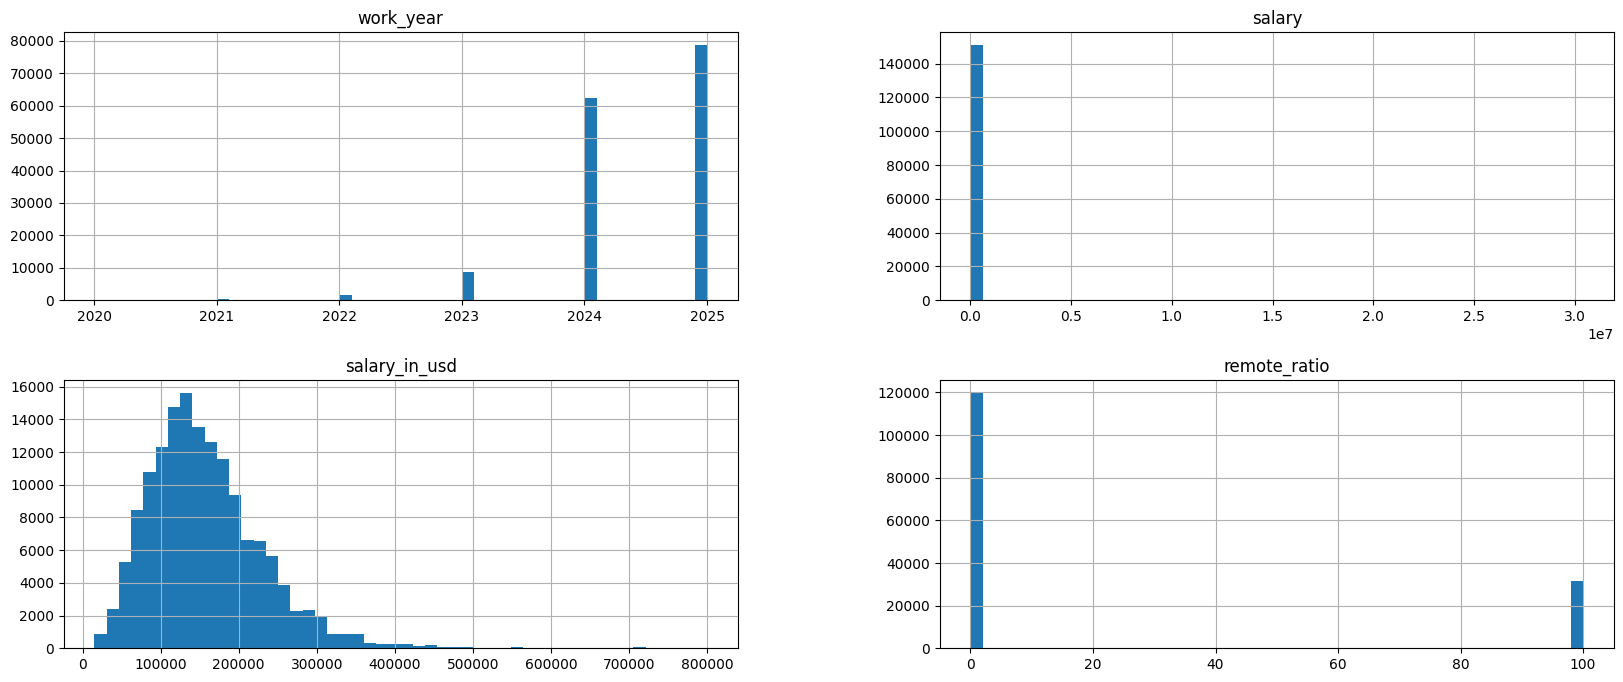

In [5]:
import seaborn as sns
from matplotlib import pyplot as plt

df.hist(bins=50,figsize=(20,8))
plt.show()

In [6]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,151445.000000,1.514450e+05,151445.000000,151445.000000
mean,2024.435313,1.628380e+05,157527.458411,20.938625
std,0.671842,2.080124e+05,74150.772377,40.620393
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060000e+05,105800.000000,0.000000
50%,2025.000000,1.470000e+05,146100.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [7]:
#Will use OneHotEncode make it categorical variable
print(df.work_year.unique())

[2025 2024 2023 2022 2020 2021]


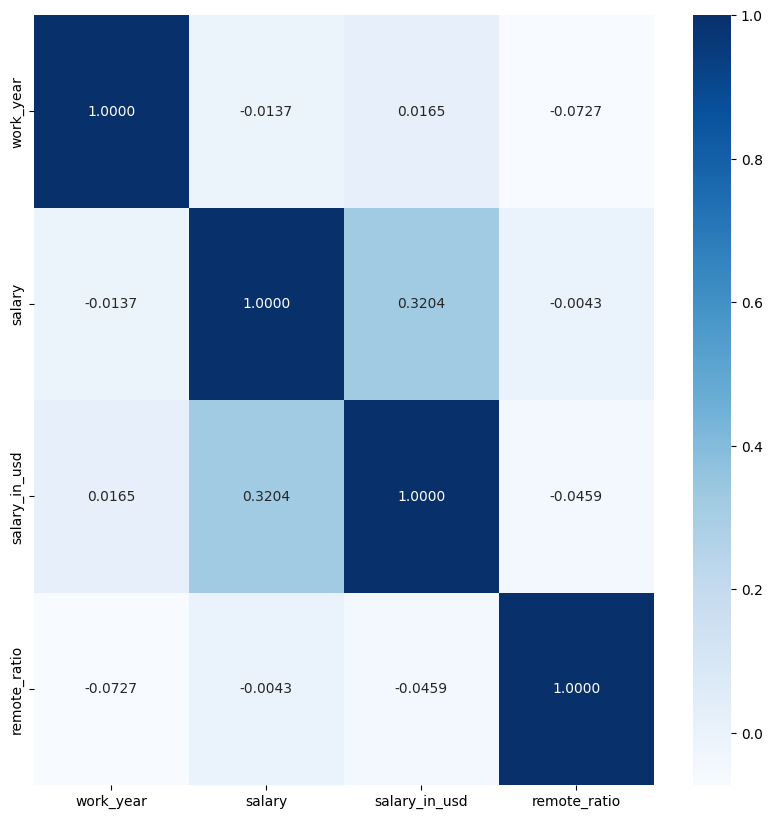

In [8]:
#Lets do a correlation plot to find the how much of a relationship will these variables have with each other
corr = df.corr(numeric_only=True)
plt.figure(figsize=(10,10))
sns.heatmap(data=corr,cmap='Blues',cbar=True,fmt='.4f',annot=True)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split

#The variables salary and salary_currency were removed to prevent data leakage, 
# as they directly encode the target variable and would 
# not be available at prediction time.

df.drop(columns=['salary','salary_currency'],inplace=True)

In [10]:
#splitting the data into training and testing data
train_set,test_set = train_test_split(df,
                                      test_size=0.2,
                                      random_state=42)

In [11]:
#test data
X_test = test_set.drop(columns=['salary_in_usd'])
Y_test = test_set['salary_in_usd']

In [12]:
#getting feature and target variables seperately
ai_features = train_set.drop(columns=['salary_in_usd'])
ai_target = train_set['salary_in_usd']

In [13]:
from sklearn.pipeline import Pipeline,make_pipeline
from sklearn.preprocessing import StandardScaler,OneHotEncoder
from sklearn.compose import ColumnTransformer

#treating work experience as ordinal variables and using only StandardScalar

cat_variables_nominal = ['experience_level',
                        'employment_type',
                        'job_title',     
                        'employee_residence',    
                        'remote_ratio',        
                        'company_location',     
                        'company_size']

cat_variables_ordinal = ['work_year']

cat_pipeline_nominal = make_pipeline(
    OneHotEncoder(handle_unknown='ignore')
    )

cat_pipeline_ordinal = make_pipeline(
    StandardScaler()
)



In [14]:
#Transforming the data 
preprocessing = ColumnTransformer(transformers=[
    ('Categorical_nominal_variables',cat_pipeline_nominal,cat_variables_nominal),
    ('Categorical Ordinal variables',cat_pipeline_ordinal,cat_variables_ordinal)
])

In [15]:
#model  
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor

model = {
    "Linear Regression" : LinearRegression(),
    "Ridge Regression" : Ridge(alpha= 0.1),
    "Lasso Regression" : Lasso(alpha=0.1),
    "Random Forest" : RandomForestRegressor(n_estimators=100,random_state=42)
}

pipeline = {
    name:Pipeline([
        ('preprocessing',preprocessing),
        ('model',model)
    ])
    for name,model in model.items()
}


In [17]:
#model fittig 
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error

for name,pipe in pipeline.items():
    pipe.fit(ai_features,ai_target)
    predictions = pipe.predict(X_test)
    rmse = root_mean_squared_error(Y_test,predictions)
    mae = mean_absolute_error(Y_test,predictions)
    r2 = r2_score(Y_test,predictions)
    print(f'{name}:MAE = {mae}')
    print(f'{name}:RMSE = {rmse:.3f}')
    print(f'{name}:R^2 = {r2}')
    

Linear Regression:MAE = 45701.35978777467
Linear Regression:RMSE = 62541.330
Linear Regression:R^2 = 0.29585210305547804
Ridge Regression:MAE = 45692.36486253377
Ridge Regression:RMSE = 62526.954
Ridge Regression:R^2 = 0.2961757784994883


c:\Users\HP\anaconda3\envs\MachineLearning\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:675: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.835e+14, tolerance: 6.644e+10
  model = cd_fast.sparse_enet_coordinate_descent(


Lasso Regression:MAE = 45685.18409085309
Lasso Regression:RMSE = 62519.202
Lasso Regression:R^2 = 0.2963502937136676
Random Forest:MAE = 44911.8702379774
Random Forest:RMSE = 61709.768
Random Forest:R^2 = 0.3144525910380479
